## Xbar and R
For the X-bar chart, the center line and control limits are defined as


$Center Line = \bar{\bar{X}},$


$UCL = \bar{\bar{X}} + A_2 \bar{R},$


$LCL = \bar{\bar{X}} - A_2 \bar{R}.$


For subgroup size $m = 6$, the control chart constant is

$A_2 = 0.483.$

For the R chart, the center line and control limits are defined as


$Center Line = \bar{R}$,

$UCL = D_4 \bar{R}$,

$LCL_R = D_3 \bar{R}.$

For subgroup size $m = 6$, the control chart constants are

$D_3 = 0, \quad D_4 = 2.004.$


### Phase1

In [54]:
import pandas as pd
import matplotlib.pyplot as plt

def make_period_subgroup_stats(file, start_hour=12, end_hour=17):
    df = pd.read_excel(file)

    df["monitordate"] = pd.to_datetime(df["monitordate"])
    df = df.sort_values("monitordate").reset_index(drop=True)

    df["date"] = df["monitordate"].dt.date
    df["hour"] = df["monitordate"].dt.hour

    # 只保留指定時段
    df_period = df[
        (df["hour"] >= start_hour) &
        (df["hour"] <= end_hour)
    ].copy()

    # 每一天的指定時段作為一個 subgroup
    stats = df_period.groupby("date")["PM2.5"].agg(
        n="count",
        x_bar="mean",
        r=lambda x: x.max() - x.min()
    ).reset_index()

    return stats

phase1_stats = make_period_subgroup_stats(
    "air_quality_202501.xlsx",
    start_hour=12,
    end_hour=17
)

phase2_stats = make_period_subgroup_stats(
    "air_quality_202601.xlsx",
    start_hour=12,
    end_hour=17
)

print("Phase 1 n distribution:")
print(phase1_stats["n"].value_counts().sort_index())

print("Phase 2 n distribution:")
print(phase2_stats["n"].value_counts().sort_index())

Phase 1 n distribution:
n
5     2
6    29
Name: count, dtype: int64
Phase 2 n distribution:
n
5     2
6    29
Name: count, dtype: int64


In [55]:
A2 = 0.483
D3 = 0
D4 = 2.004

x_bar_bar = phase1_stats["x_bar"].mean()
r_bar = phase1_stats["r"].mean()

xbar_cl = x_bar_bar
xbar_ucl = x_bar_bar + A2 * r_bar
xbar_lcl = x_bar_bar - A2 * r_bar

r_cl = r_bar
r_ucl = D4 * r_bar
r_lcl = D3 * r_bar

print("X-bar Chart Limits")
print("UCL =", xbar_ucl)
print("CL  =", xbar_cl)
print("LCL =", xbar_lcl)

print("\nR Chart Limits")
print("UCL =", r_ucl)
print("CL  =", r_cl)
print("LCL =", r_lcl)

X-bar Chart Limits
UCL = 15.91563440860215
CL  = 12.08279569892473
LCL = 8.24995698924731

R Chart Limits
UCL = 15.902709677419354
CL  = 7.935483870967742
LCL = 0.0


R chart out-of-control groups:
          date  n      x_bar     r  out_of_control_R
8   2025-01-09  6  19.333333  18.0              True
21  2025-01-22  6  39.666667  30.0              True


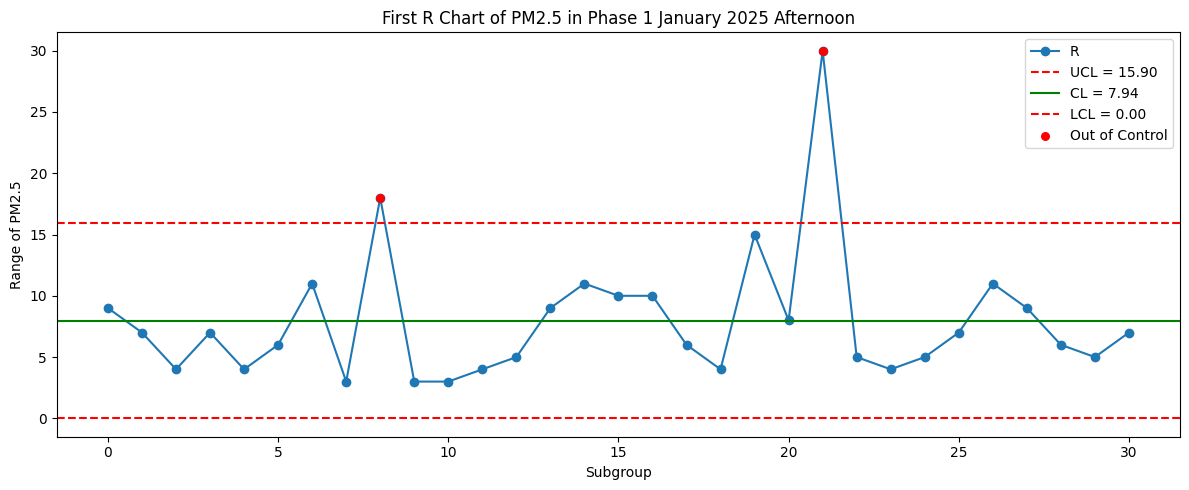

In [56]:
import matplotlib.pyplot as plt

# 檢查超出管制界限的 subgroup
phase1_stats["out_of_control_R"] = (
    (phase1_stats["r"] > r_ucl) |
    (phase1_stats["r"] < r_lcl)
)

print("R chart out-of-control groups:")
print(phase1_stats[phase1_stats["out_of_control_R"]])

plt.figure(figsize=(12, 5))

plt.plot(
    phase1_stats.index,
    phase1_stats["r"],
    marker="o",
    linestyle="-",
    label="R"
)

plt.axhline(r_ucl, color="red", linestyle="--", label=f"UCL = {r_ucl:.2f}")
plt.axhline(r_cl, color="green", linestyle="-", label=f"CL = {r_cl:.2f}")
plt.axhline(r_lcl, color="red", linestyle="--", label=f"LCL = {r_lcl:.2f}")

# 標出超出管制界限的點
out_points = phase1_stats[phase1_stats["out_of_control_R"]]

plt.scatter(
    out_points.index,
    out_points["r"],
    color="red",
    s=30,
    zorder=5,
    label="Out of Control"
)

plt.title("First R Chart of PM2.5 in Phase 1 January 2025 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Range of PM2.5")
plt.legend()

plt.tight_layout()
plt.show()                                                                                                                                              

In [57]:
# 移除第一次 R chart 中 out-of-control 的 subgroup
phase1_clean = phase1_stats[~phase1_stats["out_of_control_R"]].copy()
phase1_clean = phase1_clean.reset_index(drop=True)

# 用清理後資料重新計算 R chart limits
r_bar_clean = phase1_clean["r"].mean()

r_cl_clean = r_bar_clean
r_ucl_clean = D4 * r_bar_clean
r_lcl_clean = D3 * r_bar_clean

print("Clean R-bar =", r_bar_clean)
print("Clean R UCL =", r_ucl_clean)
print("Clean R CL =", r_cl_clean)
print("Clean R LCL =", r_lcl_clean)

Clean R-bar = 6.827586206896552
Clean R UCL = 13.68248275862069
Clean R CL = 6.827586206896552
Clean R LCL = 0.0


R chart out-of-control groups after cleaning:
          date  n  x_bar     r  out_of_control_R  out_of_control_R_clean
18  2025-01-20  6   15.5  15.0             False                    True


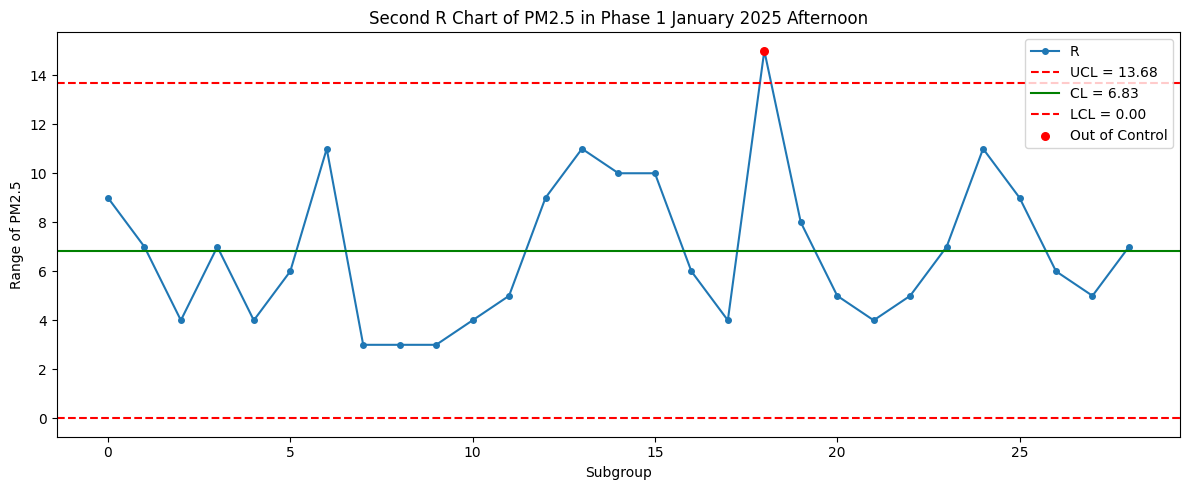

In [58]:
# 檢查清理後資料是否仍超出新的 R chart limits
phase1_clean["out_of_control_R_clean"] = (
    (phase1_clean["r"] > r_ucl_clean) |
    (phase1_clean["r"] < r_lcl_clean)
)

print("R chart out-of-control groups after cleaning:")
print(phase1_clean[phase1_clean["out_of_control_R_clean"]])

# 畫清理後 R chart
plt.figure(figsize=(12, 5))

plt.plot(
    phase1_clean.index,
    phase1_clean["r"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="R"
)

plt.axhline(
    r_ucl_clean,
    color="red",
    linestyle="--",
    label=f"UCL = {r_ucl_clean:.2f}"
)

plt.axhline(
    r_cl_clean,
    color="green",
    linestyle="-",
    label=f"CL = {r_cl_clean:.2f}"
)

plt.axhline(
    r_lcl_clean,
    color="red",
    linestyle="--",
    label=f"LCL = {r_lcl_clean:.2f}"
)

out_points_clean = phase1_clean[phase1_clean["out_of_control_R_clean"]]

plt.scatter(
    out_points_clean.index,
    out_points_clean["r"],
    color="red",
    s=30,
    zorder=5,
    label="Out of Control"
)

plt.title("Second R Chart of PM2.5 in Phase 1 January 2025 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Range of PM2.5")
plt.legend()

plt.tight_layout()
plt.show()

In [59]:
# 再刪一次：移除 First Cleaned R Chart 中仍 out-of-control 的點
phase1_clean2 = phase1_clean[~phase1_clean["out_of_control_R_clean"]].copy()
phase1_clean2 = phase1_clean2.reset_index(drop=True)

# 重新計算第二次清理後的 R chart limits
r_bar_clean2 = phase1_clean2["r"].mean()

r_cl_clean2 = r_bar_clean2
r_ucl_clean2 = D4 * r_bar_clean2
r_lcl_clean2 = D3 * r_bar_clean2

print("Second Clean R-bar =", r_bar_clean2)
print("Second Clean R UCL =", r_ucl_clean2)
print("Second Clean R CL =", r_cl_clean2)
print("Second Clean R LCL =", r_lcl_clean2)

Second Clean R-bar = 6.535714285714286
Second Clean R UCL = 13.097571428571428
Second Clean R CL = 6.535714285714286
Second Clean R LCL = 0.0


R chart out-of-control groups after second cleaning:
Empty DataFrame
Columns: [date, n, x_bar, r, out_of_control_R, out_of_control_R_clean, out_of_control_R_clean2]
Index: []
Remaining out-of-control count = 0


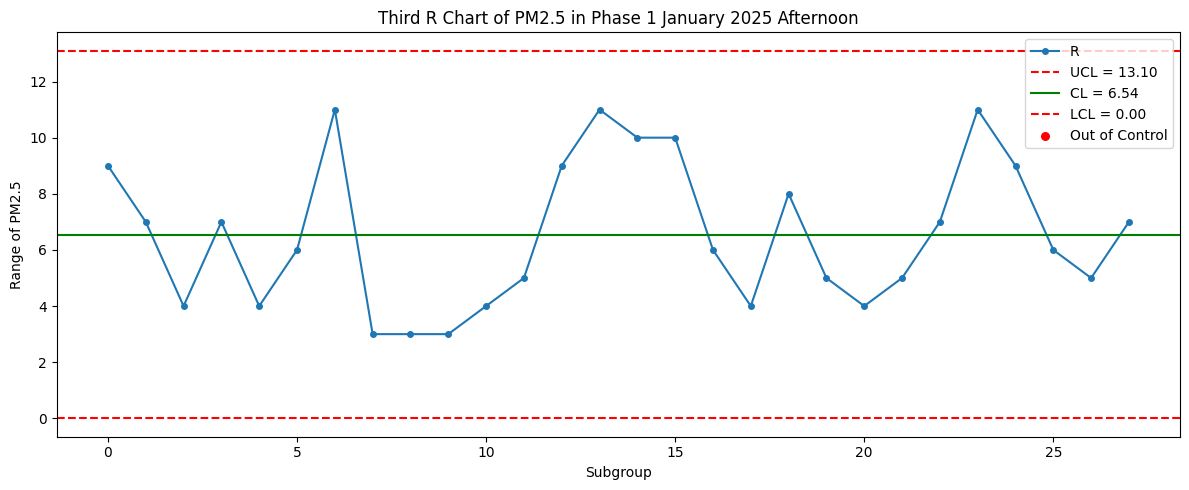

In [60]:
import matplotlib.pyplot as plt
# 檢查第二次清理後是否還有超界點
phase1_clean2["out_of_control_R_clean2"] = (
    (phase1_clean2["r"] > r_ucl_clean2) |
    (phase1_clean2["r"] < r_lcl_clean2)
)

print("R chart out-of-control groups after second cleaning:")
print(phase1_clean2[phase1_clean2["out_of_control_R_clean2"]])

print("Remaining out-of-control count =",
      phase1_clean2["out_of_control_R_clean2"].sum())
plt.figure(figsize=(12, 5))

plt.plot(
    phase1_clean2.index,
    phase1_clean2["r"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="R"
)

plt.axhline(
    r_ucl_clean2,
    color="red",
    linestyle="--",
    label=f"UCL = {r_ucl_clean2:.2f}"
)

plt.axhline(
    r_cl_clean2,
    color="green",
    linestyle="-",
    label=f"CL = {r_cl_clean2:.2f}"
)

plt.axhline(
    r_lcl_clean2,
    color="red",
    linestyle="--",
    label=f"LCL = {r_lcl_clean2:.2f}"
)

out_points_clean2 = phase1_clean2[phase1_clean2["out_of_control_R_clean2"]]

plt.scatter(
    out_points_clean2.index,
    out_points_clean2["r"],
    color="red",
    s=30,
    zorder=5,
    label="Out of Control"
)

plt.title("Third R Chart of PM2.5 in Phase 1 January 2025 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Range of PM2.5")
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
x_bar_bar_clean2 = phase1_clean2["x_bar"].mean()
r_bar_clean2 = phase1_clean2["r"].mean()

xbar_cl_clean2 = x_bar_bar_clean2
xbar_ucl_clean2 = x_bar_bar_clean2 + A2 * r_bar_clean2
xbar_lcl_clean2 = x_bar_bar_clean2 - A2 * r_bar_clean2

print("X-bar Chart Limits after R-chart cleaning")
print("X-bar-bar =", x_bar_bar_clean2)
print("R-bar =", r_bar_clean2)
print("UCL =", xbar_ucl_clean2)
print("CL  =", xbar_cl_clean2)
print("LCL =", xbar_lcl_clean2)

X-bar Chart Limits after R-chart cleaning
X-bar-bar = 10.716666666666667
R-bar = 6.535714285714286
UCL = 13.873416666666667
CL  = 10.716666666666667
LCL = 7.559916666666667


X-bar chart out-of-control groups:
          date  n      x_bar     r  out_of_control_R  out_of_control_R_clean  \
5   2025-01-06  6  20.833333   6.0             False                   False   
12  2025-01-14  6  19.166667   9.0             False                   False   
13  2025-01-15  6  28.166667  11.0             False                   False   
18  2025-01-21  6  19.000000   8.0             False                   False   

    out_of_control_R_clean2  out_of_control_xbar  
5                     False                 True  
12                    False                 True  
13                    False                 True  
18                    False                 True  
X-bar out-of-control count = 4


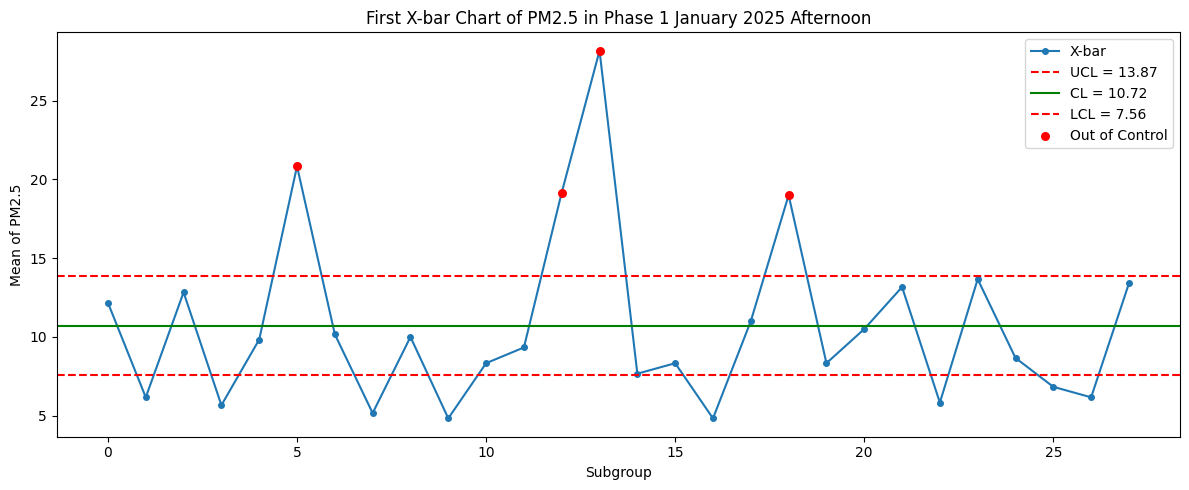

In [62]:

# 判斷 X-bar 是否超出管制界限
phase1_clean2["out_of_control_xbar"] = (
    (phase1_clean2["x_bar"] > xbar_ucl_clean2) 
)

print("X-bar chart out-of-control groups:")
print(phase1_clean2[phase1_clean2["out_of_control_xbar"]])

print(
    "X-bar out-of-control count =",
    phase1_clean2["out_of_control_xbar"].sum()
)

# 畫 X-bar chart
plt.figure(figsize=(12, 5))

plt.plot(
    phase1_clean2.index,
    phase1_clean2["x_bar"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="X-bar"
)

plt.axhline(
    xbar_ucl_clean2,
    color="red",
    linestyle="--",
    label=f"UCL = {xbar_ucl_clean2:.2f}"
)

plt.axhline(
    xbar_cl_clean2,
    color="green",
    linestyle="-",
    label=f"CL = {xbar_cl_clean2:.2f}"
)

plt.axhline(
    xbar_lcl_clean2,
    color="red",
    linestyle="--",
    label=f"LCL = {xbar_lcl_clean2:.2f}"
)

# 標出 out-of-control 點
out_points_xbar = phase1_clean2[phase1_clean2["out_of_control_xbar"]]

plt.scatter(
    out_points_xbar.index,
    out_points_xbar["x_bar"],
    color="red",
    s=30,
    zorder=5,
    label="Out of Control"
)

plt.title("First X-bar Chart of PM2.5 in Phase 1 January 2025 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Mean of PM2.5")
plt.legend()
plt.tight_layout()
plt.show()

In [63]:
phase1_xbar_clean = phase1_clean2[
    ~phase1_clean2["out_of_control_xbar"]
].copy()

phase1_xbar_clean = phase1_xbar_clean.reset_index(drop=True)

x_bar_bar_xclean = phase1_xbar_clean["x_bar"].mean()
r_bar_xclean = phase1_xbar_clean["r"].mean()

xbar_cl_xclean = x_bar_bar_xclean
xbar_ucl_xclean = x_bar_bar_xclean + A2 * r_bar_xclean
xbar_lcl_xclean = x_bar_bar_xclean - A2 * r_bar_xclean

print("\nAfter removing X-bar out-of-control points")
print("X-bar-bar =", x_bar_bar_xclean)
print("R-bar =", r_bar_xclean)
print("UCL =", xbar_ucl_xclean)
print("CL  =", xbar_cl_xclean)
print("LCL =", xbar_lcl_xclean)



After removing X-bar out-of-control points
X-bar-bar = 8.870833333333334
R-bar = 6.208333333333333
UCL = 11.869458333333334
CL  = 8.870833333333334
LCL = 5.872208333333334


Remaining X-bar out-of-control groups:
          date  n      x_bar     r  out_of_control_R  out_of_control_R_clean  \
0   2025-01-01  6  12.166667   9.0             False                   False   
2   2025-01-03  6  12.833333   4.0             False                   False   
17  2025-01-25  6  13.166667   5.0             False                   False   
19  2025-01-27  6  13.666667  11.0             False                   False   
23  2025-01-31  5  13.400000   7.0             False                   False   

    out_of_control_R_clean2  out_of_control_xbar  out_of_control_xbar_recheck  
0                     False                False                         True  
2                     False                False                         True  
17                    False                False                         True  
19                    False                False                         True  
23                    False                False                         True  


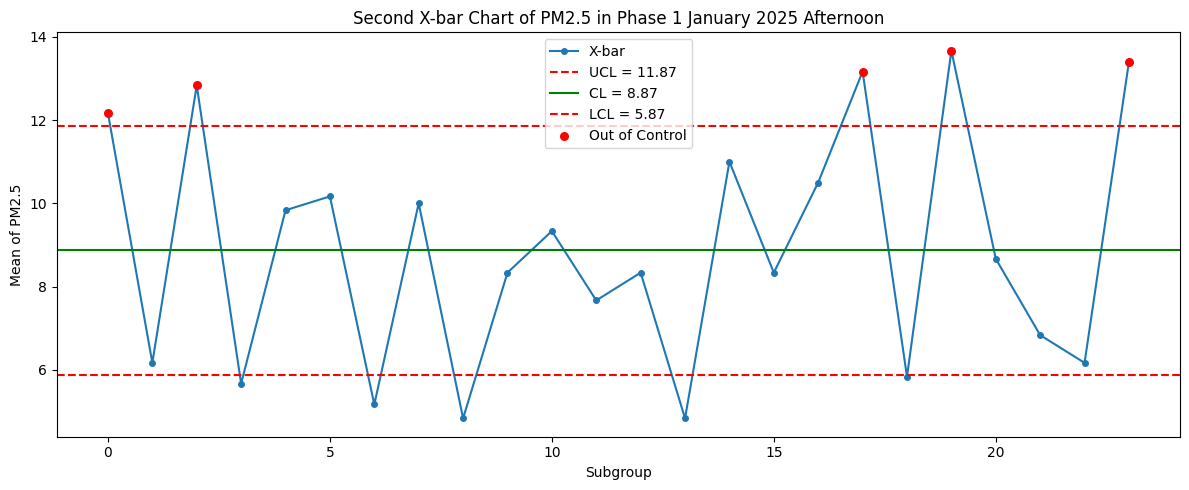

In [64]:
phase1_xbar_clean["out_of_control_xbar_recheck"] = (
    (phase1_xbar_clean["x_bar"] > xbar_ucl_xclean) 
)

out_points_xbar_recheck = phase1_xbar_clean[
    phase1_xbar_clean["out_of_control_xbar_recheck"]
]

print("Remaining X-bar out-of-control groups:")
print(out_points_xbar_recheck)

print("Remaining X-bar out-of-control count =", len(out_points_xbar_recheck))

plt.figure(figsize=(12, 5))

plt.plot(
    phase1_xbar_clean.index,
    phase1_xbar_clean["x_bar"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="X-bar"
)

plt.axhline(xbar_ucl_xclean, color="red", linestyle="--", label=f"UCL = {xbar_ucl_xclean:.2f}")
plt.axhline(xbar_cl_xclean, color="green", linestyle="-", label=f"CL = {xbar_cl_xclean:.2f}")
plt.axhline(xbar_lcl_xclean, color="red", linestyle="--", label=f"LCL = {xbar_lcl_xclean:.2f}")

plt.scatter(
    out_points_xbar_recheck.index,
    out_points_xbar_recheck["x_bar"],
    color="red",
    s=30,
    zorder=5,
    label="Out of Control"
)

plt.title("Second X-bar Chart of PM2.5 in Phase 1 January 2025 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Mean of PM2.5")
plt.legend()
plt.tight_layout()
plt.show()

In [65]:
phase1_xbar_clean2 = phase1_xbar_clean[
    ~phase1_xbar_clean["out_of_control_xbar_recheck"]
].copy()

phase1_xbar_clean2 = phase1_xbar_clean2.reset_index(drop=True)

# 重新計算新的 X-bar chart limits
x_bar_bar_xclean2 = phase1_xbar_clean2["x_bar"].mean()
r_bar_xclean2 = phase1_xbar_clean2["r"].mean()

xbar_cl_xclean2 = x_bar_bar_xclean2
xbar_ucl_xclean2 = x_bar_bar_xclean2 + A2 * r_bar_xclean2
xbar_lcl_xclean2 = x_bar_bar_xclean2 - A2 * r_bar_xclean2

print("\nAfter removing X-bar out-of-control points again")
print("X-bar-bar =", x_bar_bar_xclean2)
print("R-bar =", r_bar_xclean2)
print("UCL =", xbar_ucl_xclean2)
print("CL  =", xbar_cl_xclean2)
print("LCL =", xbar_lcl_xclean2)



After removing X-bar out-of-control points again
X-bar-bar = 7.771929824561403
R-bar = 5.947368421052632
UCL = 10.644508771929825
CL  = 7.771929824561403
LCL = 4.899350877192982


Remaining X-bar out-of-control groups after second cleaning:
          date  n  x_bar    r  out_of_control_R  out_of_control_R_clean  \
12  2025-01-19  5   11.0  4.0             False                   False   

    out_of_control_R_clean2  out_of_control_xbar  out_of_control_xbar_recheck  \
12                    False                False                        False   

    out_of_control_xbar_recheck2  
12                          True  
Remaining X-bar out-of-control count = 1


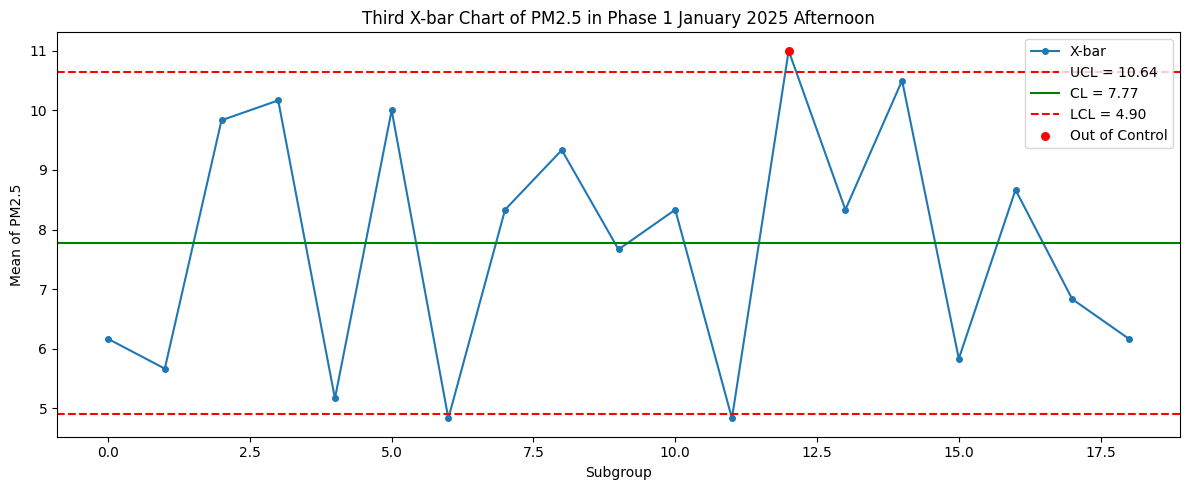

In [66]:
# 再檢查一次是否還有超界點
phase1_xbar_clean2["out_of_control_xbar_recheck2"] = (
    (phase1_xbar_clean2["x_bar"] > xbar_ucl_xclean2) 
)

out_points_xbar_recheck2 = phase1_xbar_clean2[
    phase1_xbar_clean2["out_of_control_xbar_recheck2"]
]

print("Remaining X-bar out-of-control groups after second cleaning:")
print(out_points_xbar_recheck2)

print("Remaining X-bar out-of-control count =", len(out_points_xbar_recheck2))

# 畫第二次清理後的 X-bar chart
plt.figure(figsize=(12, 5))

plt.plot(
    phase1_xbar_clean2.index,
    phase1_xbar_clean2["x_bar"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="X-bar"
)

plt.axhline(
    xbar_ucl_xclean2,
    color="red",
    linestyle="--",
    label=f"UCL = {xbar_ucl_xclean2:.2f}"
)

plt.axhline(
    xbar_cl_xclean2,
    color="green",
    linestyle="-",
    label=f"CL = {xbar_cl_xclean2:.2f}"
)

plt.axhline(
    xbar_lcl_xclean2,
    color="red",
    linestyle="--",
    label=f"LCL = {xbar_lcl_xclean2:.2f}"
)

plt.scatter(
    out_points_xbar_recheck2.index,
    out_points_xbar_recheck2["x_bar"],
    color="red",
    s=30,
    zorder=5,
    label="Out of Control"
)

plt.title("Third X-bar Chart of PM2.5 in Phase 1 January 2025 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Mean of PM2.5")
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
# 第三次清理：移除第二次清理後仍高於 UCL 的 X-bar subgroup
phase1_xbar_clean3 = phase1_xbar_clean2[
    ~phase1_xbar_clean2["out_of_control_xbar_recheck2"]
].copy()

phase1_xbar_clean3 = phase1_xbar_clean3.reset_index(drop=True)

# 重新計算第三次清理後的 X-bar chart limits
x_bar_bar_xclean3 = phase1_xbar_clean3["x_bar"].mean()
r_bar_xclean3 = phase1_xbar_clean3["r"].mean()

xbar_cl_xclean3 = x_bar_bar_xclean3
xbar_ucl_xclean3 = x_bar_bar_xclean3 + A2 * r_bar_xclean3
xbar_lcl_xclean3 = x_bar_bar_xclean3 - A2 * r_bar_xclean3

print("\nAfter removing X-bar out-of-control points third time")
print("X-bar-bar =", x_bar_bar_xclean3)
print("R-bar =", r_bar_xclean3)
print("UCL =", xbar_ucl_xclean3)
print("CL  =", xbar_cl_xclean3)
print("LCL =", xbar_lcl_xclean3)

# 再檢查第三次清理後是否還有高於 UCL 的點
phase1_xbar_clean3["out_of_control_xbar_recheck3"] = (
    phase1_xbar_clean3["x_bar"] > xbar_ucl_xclean3
)

out_points_xbar_recheck3 = phase1_xbar_clean3[
    phase1_xbar_clean3["out_of_control_xbar_recheck3"]
]

print("Remaining X-bar out-of-control groups after third cleaning:")
print(out_points_xbar_recheck3)

print("Remaining X-bar out-of-control count =", len(out_points_xbar_recheck3))


After removing X-bar out-of-control points third time
X-bar-bar = 7.592592592592592
R-bar = 6.055555555555555
UCL = 10.517425925925924
CL  = 7.592592592592592
LCL = 4.667759259259259
Remaining X-bar out-of-control groups after third cleaning:
Empty DataFrame
Columns: [date, n, x_bar, r, out_of_control_R, out_of_control_R_clean, out_of_control_R_clean2, out_of_control_xbar, out_of_control_xbar_recheck, out_of_control_xbar_recheck2, out_of_control_xbar_recheck3]
Index: []
Remaining X-bar out-of-control count = 0


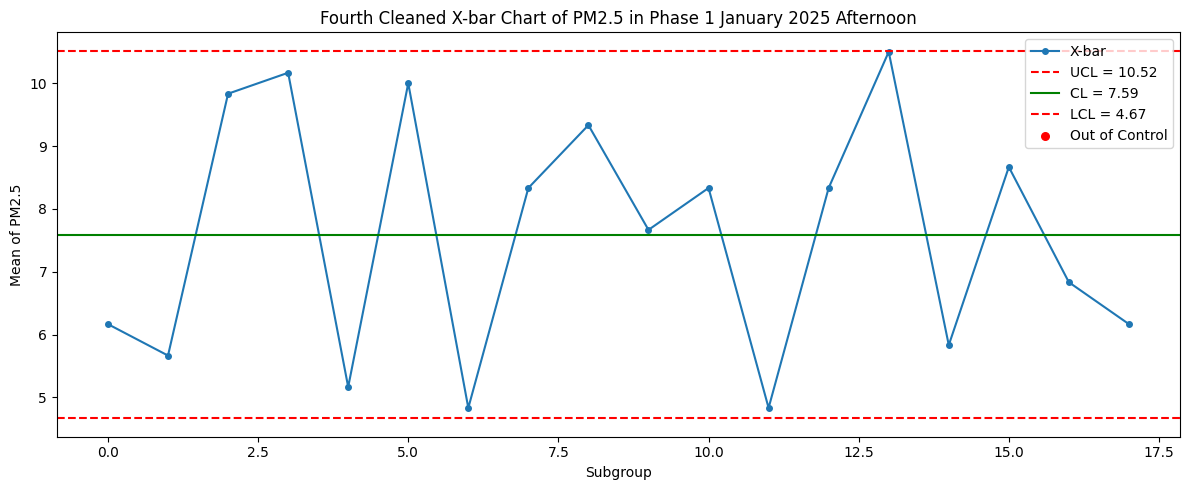

In [68]:
# 畫第三次清理後的 X-bar chart
plt.figure(figsize=(12, 5))

plt.plot(
    phase1_xbar_clean3.index,
    phase1_xbar_clean3["x_bar"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="X-bar"
)

plt.axhline(
    xbar_ucl_xclean3,
    color="red",
    linestyle="--",
    label=f"UCL = {xbar_ucl_xclean3:.2f}"
)

plt.axhline(
    xbar_cl_xclean3,
    color="green",
    linestyle="-",
    label=f"CL = {xbar_cl_xclean3:.2f}"
)

plt.axhline(
    xbar_lcl_xclean3,
    color="red",
    linestyle="--",
    label=f"LCL = {xbar_lcl_xclean3:.2f}"
)

plt.scatter(
    out_points_xbar_recheck3.index,
    out_points_xbar_recheck3["x_bar"],
    color="red",
    s=30,
    zorder=5,
    label="Out of Control"
)

plt.title("Fourth Cleaned X-bar Chart of PM2.5 in Phase 1 January 2025 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Mean of PM2.5")
plt.legend()
plt.tight_layout()
plt.show()

### Final

In [69]:
### Final
# =========================
# Final Phase 1 Control Limits
# =========================

# 使用第四次清理後的 Phase 1 資料作為 final baseline
phase1_final = phase1_xbar_clean3.copy()

# Final X-bar chart parameters
xbar_centerline_final = phase1_final["x_bar"].mean()
rbar_final = phase1_final["r"].mean()

xbar_ucl_final = xbar_centerline_final + A2 * rbar_final
xbar_lcl_final = xbar_centerline_final - A2 * rbar_final

# Final R chart parameters
rchart_centerline_final = rbar_final
rchart_ucl_final = D4 * rbar_final
rchart_lcl_final = D3 * rbar_final

print("Final Phase 1 subgroup count =", len(phase1_final))

print("\nFinal X-bar Chart Limits")
print("X-bar UCL =", xbar_ucl_final)
print("X-bar Center Line =", xbar_centerline_final)
print("X-bar LCL =", xbar_lcl_final)

print("\nFinal R Chart Limits")
print("R Chart UCL =", rchart_ucl_final)
print("R Chart Center Line =", rchart_centerline_final)
print("R Chart LCL =", rchart_lcl_final)

Final Phase 1 subgroup count = 18

Final X-bar Chart Limits
X-bar UCL = 10.517425925925924
X-bar Center Line = 7.592592592592592
X-bar LCL = 4.667759259259259

Final R Chart Limits
R Chart UCL = 12.135333333333334
R Chart Center Line = 6.055555555555555
R Chart LCL = 0.0


### Phase 2

In [70]:
phase2_stats["out_of_control_xbar"] = (
    (phase2_stats["x_bar"] > xbar_ucl_final) 
)
print("Phase 2 X-bar out-of-control groups:")
print(phase2_stats[phase2_stats["out_of_control_xbar"]])

print(
    "Phase 2 X-bar out-of-control count =",
    phase2_stats["out_of_control_xbar"].sum()
)

Phase 2 X-bar out-of-control groups:
          date  n      x_bar     r  out_of_control_xbar
1   2026-01-02  6  13.833333   5.0                 True
3   2026-01-04  6  12.500000  12.0                 True
4   2026-01-05  6  16.333333   6.0                 True
5   2026-01-06  6  37.000000  12.0                 True
6   2026-01-07  6  22.500000   8.0                 True
7   2026-01-08  6  19.500000   7.0                 True
8   2026-01-09  6  15.166667   8.0                 True
10  2026-01-11  6  21.333333   8.0                 True
11  2026-01-12  6  19.666667  12.0                 True
12  2026-01-13  5  19.200000  11.0                 True
13  2026-01-14  6  12.666667   6.0                 True
14  2026-01-15  6  15.833333  10.0                 True
15  2026-01-16  6  20.500000   4.0                 True
16  2026-01-17  6  16.500000  11.0                 True
17  2026-01-18  6  17.333333  10.0                 True
18  2026-01-19  6  19.833333  10.0                 True
25  2026-01

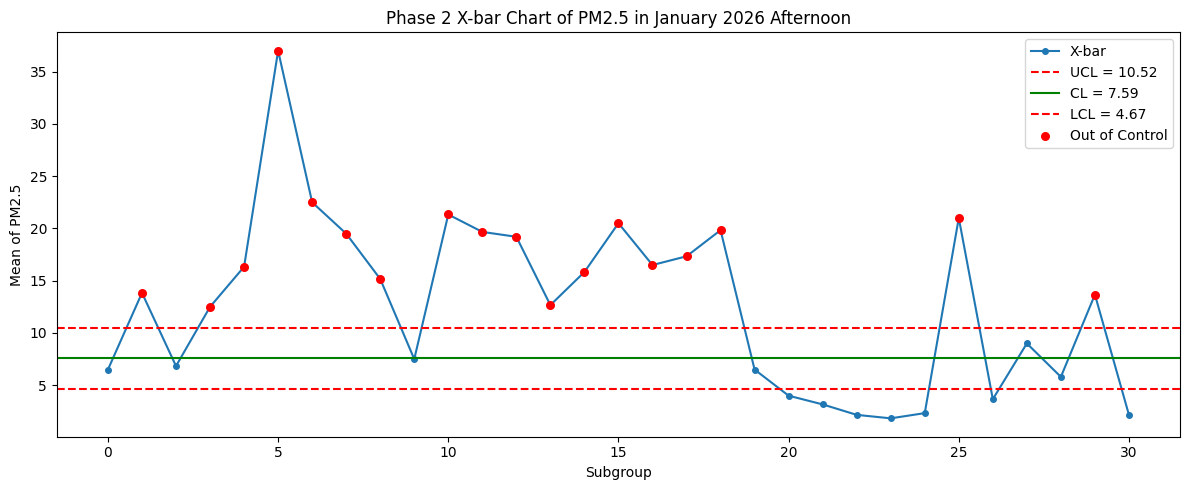

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    phase2_stats.index,
    phase2_stats["x_bar"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="X-bar"
)

plt.axhline(xbar_ucl_final, color="red", linestyle="--", label=f"UCL = {xbar_ucl_final:.2f}")
plt.axhline(xbar_centerline_final, color="green", linestyle="-", label=f"CL = {xbar_centerline_final:.2f}")
plt.axhline(xbar_lcl_final, color="red", linestyle="--", label=f"LCL = {xbar_lcl_final:.2f}")
out_points_phase2_xbar = phase2_stats[phase2_stats["out_of_control_xbar"]]

plt.scatter(
    out_points_phase2_xbar.index,
    out_points_phase2_xbar["x_bar"],
    color="red",
    s=30,
    zorder=5,
    label="Out of Control"
)

plt.title("Phase 2 X-bar Chart of PM2.5 in January 2026 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Mean of PM2.5")
plt.legend()
plt.tight_layout()
plt.show()

In [72]:
phase2_stats["out_of_control_R"] = (
    (phase2_stats["r"] > rchart_ucl_final) |
    (phase2_stats["r"] < rchart_lcl_final)
)
# Final R chart parameters

print("Phase 2 R chart out-of-control groups:")
print(phase2_stats[phase2_stats["out_of_control_R"]])

print(
    "Phase 2 R chart out-of-control count =",
    phase2_stats["out_of_control_R"].sum()
)

Phase 2 R chart out-of-control groups:
          date  n      x_bar     r  out_of_control_xbar  out_of_control_R
25  2026-01-26  6  21.000000  13.0                 True              True
29  2026-01-30  6  13.666667  13.0                 True              True
Phase 2 R chart out-of-control count = 2


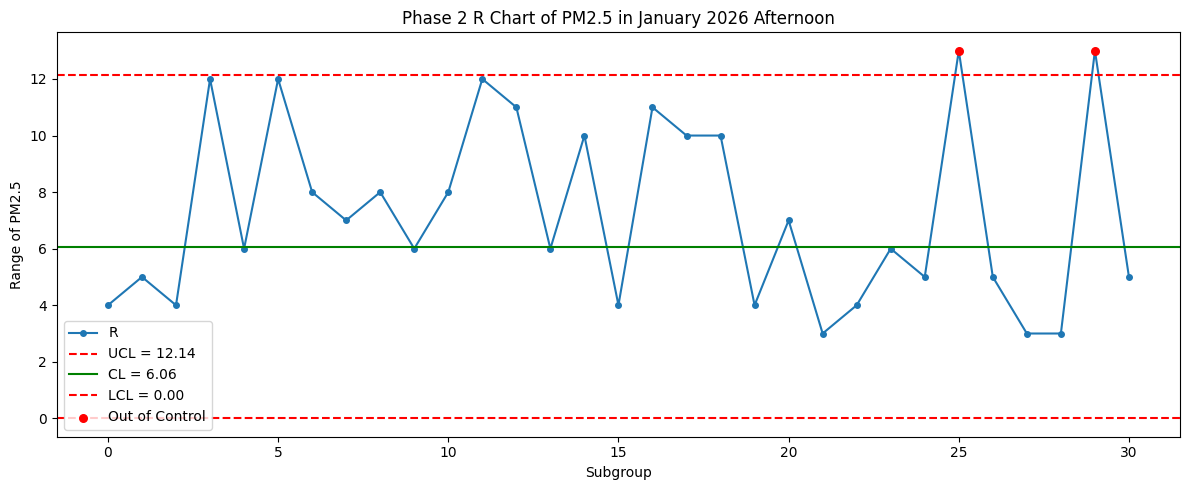

In [73]:
plt.figure(figsize=(12, 5))

plt.plot(
    phase2_stats.index,
    phase2_stats["r"],
    marker="o",
    markersize=4,
    linestyle="-",
    label="R"
)

plt.axhline(rchart_ucl_final, color="red", linestyle="--", label=f"UCL = {rchart_ucl_final:.2f}")
plt.axhline(rchart_centerline_final, color="green", linestyle="-", label=f"CL = {rchart_centerline_final:.2f}")
plt.axhline(rchart_lcl_final, color="red", linestyle="--", label=f"LCL = {rchart_lcl_final :.2f}")

out_points_phase2_R = phase2_stats[phase2_stats["out_of_control_R"]]

plt.scatter(
    out_points_phase2_R.index,
    out_points_phase2_R["r"],
    color="red",
    s=30,
    zorder=5,
    label="Out of Control"
)

plt.title("Phase 2 R Chart of PM2.5 in January 2026 Afternoon")
plt.xlabel("Subgroup")
plt.ylabel("Range of PM2.5")
plt.legend()
plt.tight_layout()
plt.show()